# Experiment 1: So sánh hai phương pháp biểu diễn văn bản Bag of Words và TF-IDF

In [2]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib


In [ ]:
df = pd.read_csv("../data/processed/IMDB Processed.csv")

NameError: name 'pd' is not defined

In [4]:
X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Bog of words

In [5]:
# 1. Khởi tạo
cv = CountVectorizer()

# 2. Fit trên train + transform
X_train_bow = cv.fit_transform(X_train)
X_test_bow = cv.transform(X_test)

joblib.dump(cv, "../../models/sentiment_analysis/bow.pkl")

['../../models/sentiment_analysis/bow.pkl']

In [6]:
print(X_train_bow.shape)
print(X_test_bow.shape)

(39661, 181691)
(9916, 181691)


## Term Frequency-Inverse Document Frequency model (TFIDF)

In [7]:
# 1. Khởi tạo TF-IDF
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2)
)

# 2. Fit trên train + transform
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
joblib.dump(tfidf, "../models/tfidf.pkl")

['../../models/sentiment_analysis/tfidf.pkl']

## Logistic Regression

In [9]:
# Sử dụng bog of words + Logistic Regression
logreg_bow = LogisticRegression(max_iter=500)

logreg_bow.fit(X_train_bow, y_train)

bow_pred = logreg_bow.predict(X_test_bow)

bow_acc = accuracy_score(y_test, bow_pred)

print("BoW Accuracy: {:.2f}%".format(bow_acc * 100))

BoW Accuracy: 88.42%


In [10]:
print("Ma trận nhầm lẫn (BOW): \n", confusion_matrix(y_test, bow_pred))
print("\n")
print(classification_report(y_test, bow_pred))

Ma trận nhầm lẫn (BOW): 
 [[4341  598]
 [ 550 4427]]


              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4939
           1       0.88      0.89      0.89      4977

    accuracy                           0.88      9916
   macro avg       0.88      0.88      0.88      9916
weighted avg       0.88      0.88      0.88      9916



In [11]:
# Sử dụng TF-IDF + Logistic Regression
logreg_tfidf = LogisticRegression(max_iter=500)

logreg_tfidf.fit(X_train_tfidf, y_train)

tfidf_pred = logreg_tfidf.predict(X_test_tfidf)

tfidf_acc = accuracy_score(y_test, tfidf_pred)

print("TF-IDF Accuracy: {:.2f}%".format(tfidf_acc * 100))

TF-IDF Accuracy: 89.55%


In [12]:
print("Ma trận nhầm lẫn (TF-IDF): \n", confusion_matrix(y_test, tfidf_pred))
print("\n")
print(classification_report(y_test, tfidf_pred))

Ma trận nhầm lẫn (TF-IDF): 
 [[4348  591]
 [ 445 4532]]


              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4939
           1       0.88      0.91      0.90      4977

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90      0.90      9916



## So sánh BoW và TF-IDF

In [13]:
print(X_train_bow.shape)
print(X_train_tfidf.shape)

(39661, 181691)
(39661, 50000)


In [14]:
print("Accuracy BoW   :", bow_acc)
print("Accuracy TF-IDF:", tfidf_acc)

Accuracy BoW   : 0.8842275110931828
Accuracy TF-IDF: 0.8955223880597015


In [17]:
import matplotlib.pyplot as plt


def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.3f}' if height < 1 else f'{int(height)}',
                 ha='center', va='bottom')

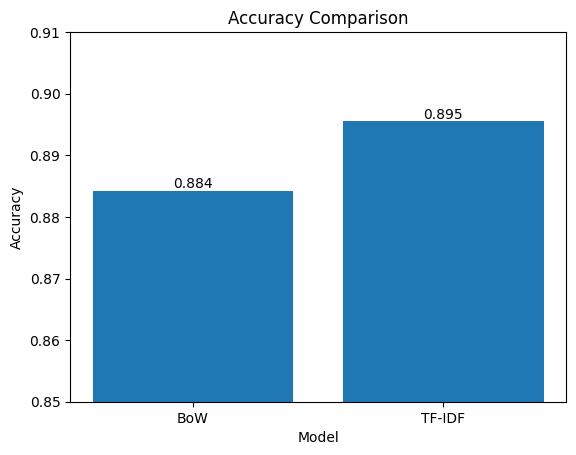

In [18]:
import matplotlib.pyplot as plt

models = ['BoW', 'TF-IDF']
accuracy = [0.8842, 0.8955]

plt.figure()
bars = plt.bar(models, accuracy)
add_labels(bars)

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy Comparison')
plt.ylim(0.85, 0.91)
plt.show()

In [15]:
print("=== BoW Classification Report ===")
print(classification_report(y_test, bow_pred))

print("=== TF-IDF Classification Report ===")
print(classification_report(y_test, tfidf_pred))

=== BoW Classification Report ===
              precision    recall  f1-score   support

           0       0.89      0.88      0.88      4939
           1       0.88      0.89      0.89      4977

    accuracy                           0.88      9916
   macro avg       0.88      0.88      0.88      9916
weighted avg       0.88      0.88      0.88      9916

=== TF-IDF Classification Report ===
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      4939
           1       0.88      0.91      0.90      4977

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90      0.90      9916



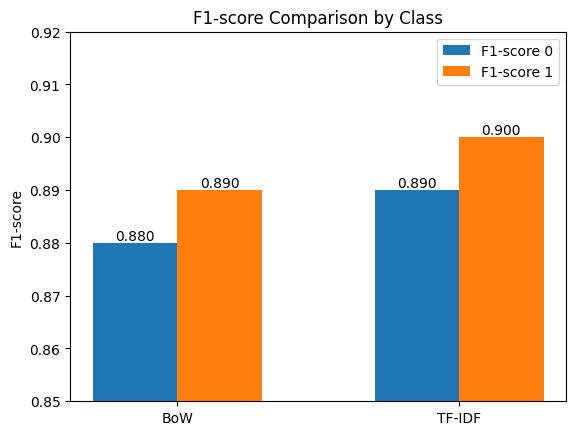

In [26]:
f1_class0 = [0.88, 0.89]
f1_class1 = [0.89, 0.90]

x = range(len(models))
plt.figure()

bars1 = plt.bar([i - 0.15 for i in x], f1_class0, width=0.3, label='F1-score 0')
bars2 = plt.bar([i + 0.15 for i in x], f1_class1, width=0.3, label='F1-score 1')

add_labels(bars1)
add_labels(bars2)

plt.xticks(list(x), models)
plt.ylabel('F1-score')
plt.title('F1-score Comparison by Class')
plt.legend()
plt.ylim(0.85, 0.92)
plt.show()

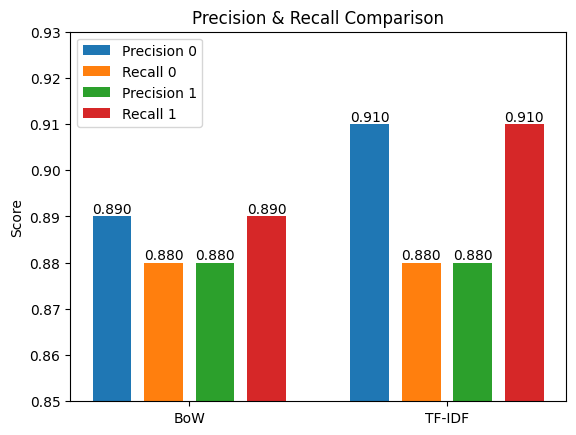

In [27]:
precision_0 = [0.89, 0.91]
recall_0    = [0.88, 0.88]

precision_1 = [0.88, 0.88]
recall_1    = [0.89, 0.91]

plt.figure()

bars1 = plt.bar([i - 0.3 for i in x], precision_0, width=0.15, label='Precision 0')
bars2 = plt.bar([i - 0.1 for i in x], recall_0,    width=0.15, label='Recall 0')
bars3 = plt.bar([i + 0.1 for i in x], precision_1, width=0.15, label='Precision 1')
bars4 = plt.bar([i + 0.3 for i in x], recall_1,    width=0.15, label='Recall 1')

for b in [bars1, bars2, bars3, bars4]:
    add_labels(b)

plt.xticks(list(x), models)
plt.ylabel('Score')
plt.title('Precision & Recall Comparison')
plt.legend()
plt.ylim(0.85, 0.93)
plt.show()

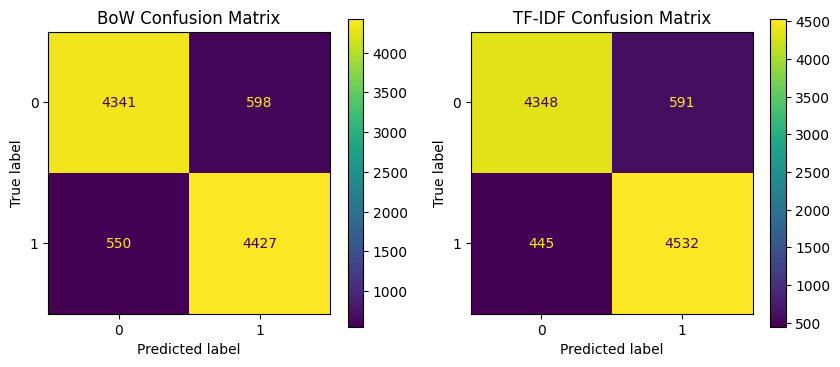

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_bow = confusion_matrix(y_test, bow_pred)
cm_tfidf = confusion_matrix(y_test, tfidf_pred)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay(cm_bow).plot(ax=axes[0])
axes[0].set_title("BoW Confusion Matrix")

ConfusionMatrixDisplay(cm_tfidf).plot(ax=axes[1])
axes[1].set_title("TF-IDF Confusion Matrix")

plt.show()

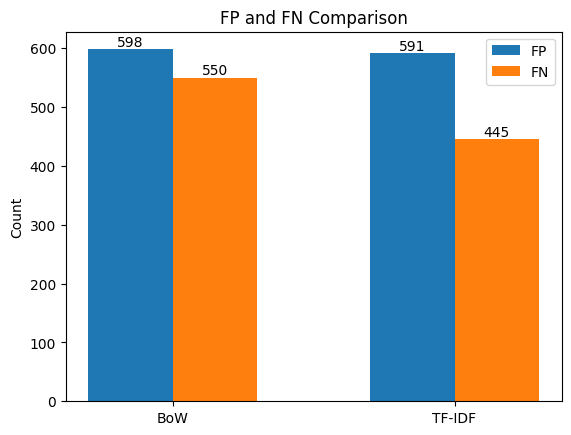

In [21]:
fp = [598, 591]
fn = [550, 445]

plt.figure()

bars1 = plt.bar([i - 0.15 for i in x], fp, width=0.3, label='FP')
bars2 = plt.bar([i + 0.15 for i in x], fn, width=0.3, label='FN')

add_labels(bars1)
add_labels(bars2)

plt.xticks(list(x), models)
plt.ylabel('Count')
plt.title('FP and FN Comparison')
plt.legend()
plt.show()